# Corpus demographics

In this notebook, we analyze the demographics of Corpus NGT (CNGT). We get the demographics by scraping the demographic information from the CNGT website. We have to clean this data before we can use it. Then, we are left with the demographics for each participant pair. It is not easy to figure out which participant is which, so the demographics stay paired. For instance, we may know that S00x and S00y are a pair and one is male and one female, but we cannot be sure if S00x is the female or male participant in that pair or if S00y is.

It is of course possible to simply assign all participants randomly to the train or test set. However, we wanted to make a semi-stratified split of the participants. This is done by first binning the participants by age, region and sex. We could only use a few categories to allow for some overlap between participants (if we use too many demographics for the codes we end up with too many unique codes).

Then, we make codes that represent their demographics. For instance, the code `A1MV` indicates that the participants are from Amsterdam (`A`), they are at least 40 years old (`1`) and the participants are male (`M` for Man) and female (`V` for Vrouw). We can now put them into the train set or into the validation/test set by stratifying.

We have a few participants that could not be found with our webscrape. Those were manually looked at before we grouped them into the train or val/test set.

In [1]:
# Imports
from bs4 import BeautifulSoup, SoupStrainer
import requests
import re

import importlib

# Keep python tools up to date
from tools import tools, constants
importlib.reload(tools)
importlib.reload(constants)

# Import all functions from the tools
from tools.tools import*
from tools.constants import PATHS # Path constants

from sklearn.model_selection import train_test_split

In [2]:
# URLs to the corpus NGT website, specifically to the search section for (glossed) videos
# We also specify that they should be translated, which weirdly finds more videos than if we don't specify it.
first_url = "https://www.corpusngt.nl/keyword-search?keys=&op=Zoeken&geglost=1&vertaald=1" # page 1
url = "https://www.corpusngt.nl/keyword-search?page={}&keys=&op=Zoeken&geglost=1&vertaald=1" # pages from 2-27 (end)

# Start a session
# Initializing it here instead of in the for-loop speeds things up
request = requests.Session()
corpus_urls = []

# Request the webpage with the redirects to all the types
for i in range(1,28):
    if i == 1:
        page = request.get(first_url)
    else:
        page = request.get(url.format(i))
    soup = BeautifulSoup(page.content, "lxml", parse_only=SoupStrainer('a')) # html.parser
    # Only filter for 'a' tags (which contain links/redirects)
    links = soup.findAll('a')
    # Links to corpus videos naturally include 'corpusvideo' in the url
    # We want to be left with only the url number for easier processing later on
    hrefs = [a['href'].replace('/corpusvideo/', '') for a in links if 'corpusvideo' in a['href']]
    hrefs = [h for h in hrefs if len(h) > 0]
    corpus_urls += hrefs

corpus_urls = list(set(corpus_urls))

print('Number of detected corpus NGT videos:', len(corpus_urls))

Number of detected corpus NGT videos: 381


In [3]:
%%time
# Clean the scraped demographics
def prepare_bs_string(s):
    s = s.replace('\n', '')
    s = re.split('[<>]', s)
    s = [x for x in s if '/' not in x and '=' not in x and len(x) > 0]
    return s

base_url = 'https://www.corpusngt.nl/corpusvideo/{}'
video_demographics = {}

demographics_path = PATHS['cngt_demographics']

if os.path.exists(demographics_path):
    video_demographics = load_dict(demographics_path)
else:
    for i, corpus_url in enumerate(corpus_urls):
        print(i, end = '\r')
        video_url = base_url.format(corpus_url)
        try:
            page = request.get(video_url)
        except:
            continue
        soup = BeautifulSoup(page.content, "lxml") # html.parser
        p1 = prepare_bs_string(str(soup.find(class_="data_p1")))
        p2 = prepare_bs_string(str(soup.find(class_="data_p2")))
        video_id = prepare_bs_string(str(soup.find(class_="metadata")))[0]
        p = p1 + ['&&'] + p2
    #     print(p1, p2, video_id)
        video_demographics[video_id] = p
    store_dict(demographics_path, video_demographics)

CPU times: total: 0 ns
Wall time: 112 ms


In [4]:
path = PATHS['cngt_eaf']
file_format = '.eaf'
cngt_files = find_files(path, file_format)

# Gives tuples like (video_id, signer_id)
signers_and_ids = [tuple(name.replace(file_format, '').split('_')[::-1]) for root, name in cngt_files]

signers_and_ids_dict = {}
for key, val in signers_and_ids:
    signers_and_ids_dict = append_to_list_in_dict(signers_and_ids_dict, key, val)

# Here, we want to make a dictionary of the format (key: participant_ids, val: demographics)
ids_demographics = {}
for key in signers_and_ids_dict:
    if key in video_demographics:
        p_str = '+'.join(signers_and_ids_dict[key])
        demographics = '||'.join(video_demographics[key])
        if '+' in p_str and '&&' in demographics:
            if not p_str in ids_demographics:
                ids_demographics = add_to_val_in_dict(ids_demographics, p_str, demographics, '')
            elif not demographics in ids_demographics[p_str]:
                ids_demographics = add_to_val_in_dict(ids_demographics, p_str, demographics, '')

In [5]:
def get_demographics(dict_):
    reg, age, sex, hand = [], [], [], []
    demos = [reg, age, sex, hand]
    for item in dict_.items():
        key, val = item
        for p in val.split('&&')[:2]: # Loop over the persons
            # Split on the demographic dividers ('Region: ...||Age: ...')
            p = [x for x in p.split('||') if len(x) > 0]
            # Get only the value (e.g if 'Region: Groningen') we only want to keep 'Groningen'
            p = [x.split(' ')[-1] for x in p]

            # Add to the corresponding demographic
            for i in range(len(demos)):
                demos[i] += [p[i]]
    return demos

demos = get_demographics(ids_demographics)

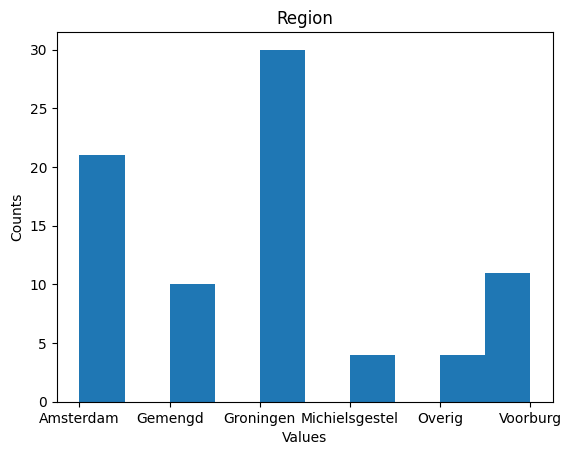

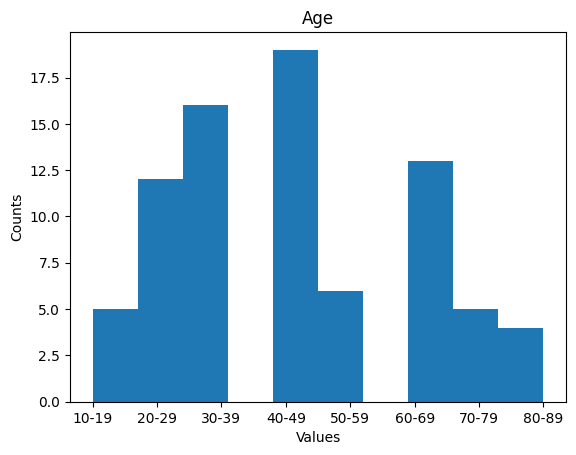

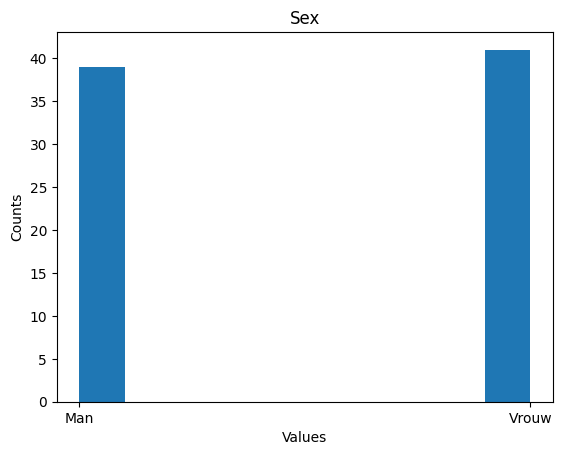

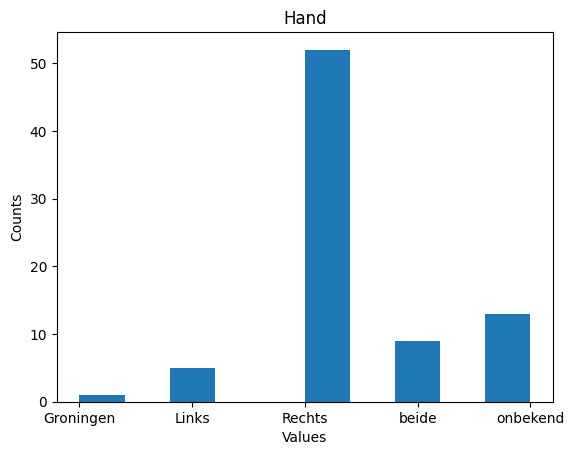

In [6]:
# Demographic distribution of the whole dataset
str_titles = ['Region', 'Age', 'Sex', 'Hand']
for i in range(len(demos)):
    demo = sorted(demos[i])
    str_title = str_titles[i]
    # For density distr. add: density = True, cumulative = True
    plt.hist(demo)
    plt.title(str_title)
    plt.xlabel('Values')
    plt.ylabel('Counts')
    plt.show()

In [7]:
# This function gets the first digit of the age
# Since all ages are above 10, '1' would indicate some age between 10-19 (first digit = 1)
# So a threshold of 4 means a threshold for age 40 (first digit = 4)
def bin_ages(age1_str, age2_str, threshold = 4):
    avg = (int(age1_str)+int(age2_str))/2
    age_bin = 1 if avg >= threshold else 0
    return age_bin

# Creating some easier-to-decipher codes of the demographics
# Where we basically take the first character/letter of each category
# And fuse them for the two participants in some manner
codes = []

# Loop over the different participant pairs
for v in list(ids_demographics.values()):
    # Get participant 1 and 2 and prepare their demo categories
    # By only keeping the first letter of each category entry
    p1, p2 = v.split('&&')[0], v.split('&&')[1]
    p1 = [x for x in p1.split('||')] # Split demos that are separated by ||
    p1 = [x.split(' ')[-1] for x in p1] # Get only the part after the colon
    p1 = [x[0] for x in p1 if len(x) > 0] # Keep only the first letter of the demographic
    
    p2 = [x for x in p2.split('||')]
    p2 = [x.split(' ')[-1] for x in p2]
    p2 = [x[0] for x in p2 if len(x) > 0][:4]
    
    # Fix an entry for part. 2 where they have 'Groningen' as their handedness
    if p2[-1] == 'G':
        p2[-1] = 'R'
    
    # Fusing the participant demographics
    p = []
    for i in range(len(p1)):
        # We discard the handedness because it makes stratifying even more difficult
        if p1[i] == p2[i] and i < 3:
            # If we're dealing with age, average the ages and bin them
            # To either < 40 or >= 40
            if i == 1:
                age_bin = bin_ages(p1[i],p2[i])
                p.append(str(age_bin))
            # If the value is the same for both participants (e.g. both from Amsterdam)
            # Then we keep only one of their values
            else: 
                p.append(p1[i])
        # If the values are different for both participants (e.g. one is male, one is female)
        # We store both, fusing them in alphabetical order (e.g. values G, A -> AG)
        else:
            if i == 1: # Average, then bin age like before
                age_bin = bin_ages(p1[i],p2[i])
                p.append(str(age_bin))
            elif i == 0 or i == 2:
                p.append(''.join(sorted([p1[i],p2[i]])))
    str_p = ''.join(p)
    codes.append(str_p)
print('Demographic codes:')
print(codes)

Demographic codes:
['A1MV', 'A1V', 'G0V', 'O0V', 'A0V', 'A0M', 'G0V', 'G1M', 'G1MV', 'G0MV', 'G0MV', 'G1MV', 'G0M', 'G0V', 'G0M', 'G1MV', 'G1V', 'G0MV', 'G1M', 'G1V', 'G1MV', 'M1MV', 'AV1M', 'V1M', 'A1V', 'G1M', 'V1V', 'M0V', 'O0V', 'G0M', 'A1MV', 'A0V', 'A0M', 'G0MV', 'V0M', 'G0M', 'A1V', 'A1M', 'V1V', 'V1M']


In [8]:
# We now still have some codes that don't occur more than once
# Which will stop us from using stratification later
# So, we group all codes which only occur once into a 'REST' category
counts = Counter(codes)
codes_2 = []
for i in range(len(codes)):
    code = codes[i]
    if counts[code] == 1:
        codes_2.append('REST')
    else:
        codes_2.append(code)
print('Demographic codes (putting single-occurrence codes as REST label)')
print(Counter(codes_2))

Demographic codes (putting single-occurrence codes as REST label)
Counter({'REST': 5, 'G1MV': 4, 'G0MV': 4, 'G0M': 4, 'A1V': 3, 'G0V': 3, 'G1M': 3, 'A1MV': 2, 'O0V': 2, 'A0V': 2, 'A0M': 2, 'G1V': 2, 'V1M': 2, 'V1V': 2})


In train: ['S029+S030', 'S031+S032', 'S003+S004', 'S013+S014', 'S089+S090', 'S075+S076', 'S087+S088', 'S043+S044', 'S065+S066', 'S015+S016', 'S021+S022', 'S077+S078', 'S045+S075', 'S035+S036', 'S069+S070', 'S009+S010', 'S023+S024', 'S083+S084', 'S033+S034', 'S005+S006', 'S037+S038', 'S007+S008', 'S017+S018', 'S001+S002', 'S067+S068', 'S025+S026']
In test: ['S073+S074', 'S019+S020', 'S085+S086', 'S027+S028', 'S081+S082', 'S041+S042', 'S051+S052', 'S071+S072', 'S057+S058', 'S011+S012', 'S047+S048', 'S079+S080', 'S045+S046', 'S039+S040']


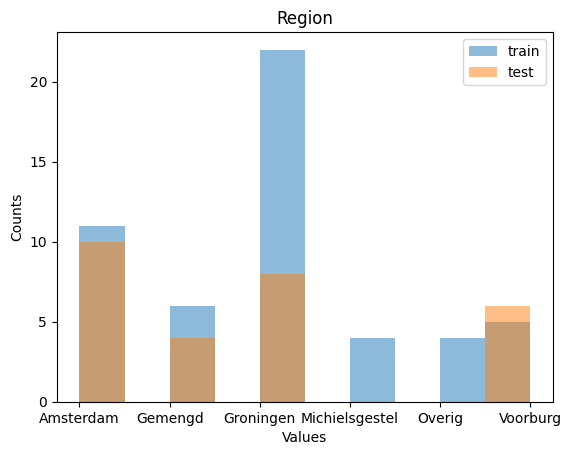

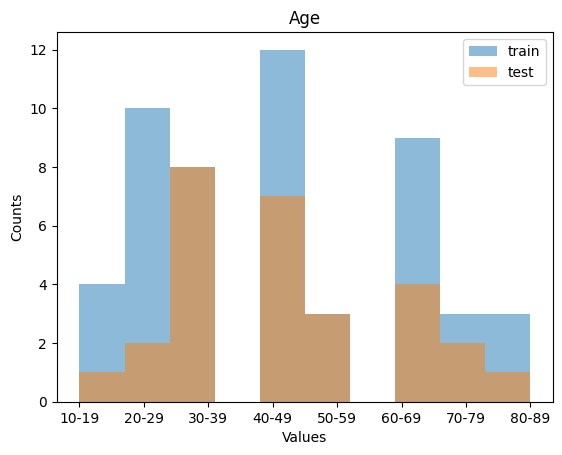

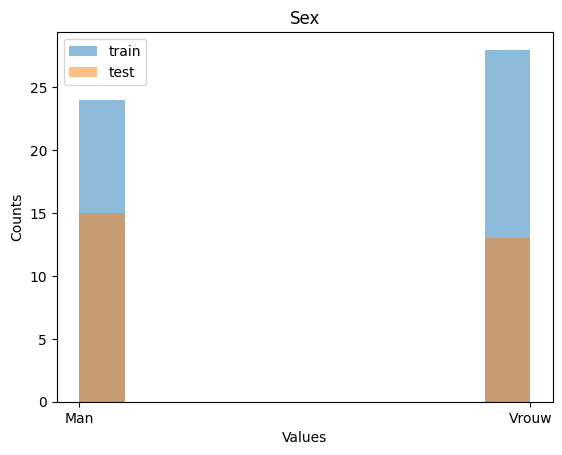

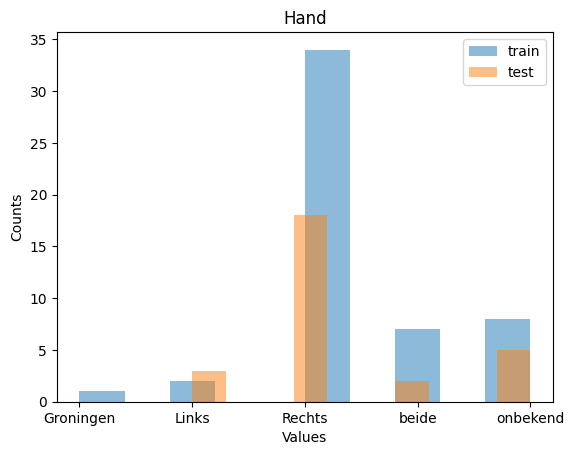

In [9]:
# Randomly sampling participants while trying to get decently even distributions 
# We achieve this using stratification of the binned demographics
# We choose a random state to make the results consistent every time
X_train, X_test, y_train, y_test = train_test_split(list(ids_demographics.items()), codes_2, test_size=0.33, stratify = codes_2, random_state=2)

train_group = dict(X_train)
test_group = dict(X_test)

demos_train = get_demographics(train_group)
demos_test = get_demographics(test_group)

print('In train:', list(train_group.keys()))
print('In test:', list(test_group.keys()))

for i in range(len(demos_train)):
    demo_train = sorted(demos_train[i])
    demo_test = sorted(demos_test[i])
    str_title = str_titles[i]
    plt.hist(demo_train, label = 'train', alpha = 0.5)
    plt.hist(demo_test, label = 'test', alpha = 0.5)
    plt.title(str_title)
    plt.legend()
    plt.ylabel('Counts')
    plt.xlabel('Values')
    plt.show()

In [10]:
# An example of what the demographics look like for a train set participant
key = list(train_group.keys())[0]
print(key, train_group[key])

S029+S030 Regio: Groningen||Leeftijd: 10-19||Geslacht: Man||Voorkeurshand: Rechts||&&||Regio: Groningen||Leeftijd: 10-19||Geslacht: Man||Voorkeurshand: onbekend


In [11]:
# Get only the IDs found through the demographics web scraping
id_pairs_partial = [tuple(sorted(x.split('+'))) for x in ids_demographics.keys()]

# Get all IDs that are in the Corpus video dataset
id_pairs_full = [tuple(sorted(x)) for x in signers_and_ids_dict.values() if len(x) > 1]

# Check (both ways) which id_pairs are missing from the corpus videos or from the website data
not_known_demos = list(set(id_pairs_full) - set(id_pairs_partial)) # Not found through webscrape
not_known_demos_2 = list(set(id_pairs_partial) - set(id_pairs_full)) # Not found in corpus

print('Not found with webscrape:', not_known_demos, '\nNot in corpus:', not_known_demos_2)

Not found with webscrape: [('S063', 'S064'), ('S061', 'S062'), ('S055', 'S056'), ('S059', 'S060'), ('S049', 'S050'), ('S091', 'S092'), ('S053', 'S054')] 
Not in corpus: []


In [12]:
# We manually add some of the participant IDs listed above to the train and test group
# While trying to keep the demographics balanced
def get_vid_ids_for_participants(groups):    
    ids = []
    
    for group in groups:
        group = group.split('+')
        for p in group:
            for key, vals in signers_and_ids_dict.items():
                for val in vals:
                    if val == p:
                        vid_id = '{}_{}'.format(key, val)
                        ids.append(vid_id)
    return ids

train_group_extended = list(train_group.keys()) + ['S091+S092', 'S063+S064', 'S062+S061', 'S060+S059', 'S049+S050']
test_group_extended = list(test_group.keys()) + ['S056+S055', 'S053+S054']

train_ids = get_vid_ids_for_participants(train_group_extended)
test_ids = get_vid_ids_for_participants(test_group_extended)

id_split = {'Train': train_ids, 'Test': test_ids}
store_dict(PATHS['CNGT_split_ids'], id_split) # We store the split of the participants here

In [13]:
num_train, num_test, num_total = len(train_ids), len(test_ids), len(train_ids) + len(test_ids)
percent_train, percent_test = round(100*num_train/num_total, 2), round(100*num_test/num_total, 2)
print('Number of train videos: {} ({}%)\ttest videos: {} ({}%)'.format(num_train, percent_train, num_test, percent_test))

Number of train videos: 636 (72.19%)	test videos: 245 (27.81%)


In [14]:
# Count the number of participants (each pair in group_extended contains 2 people so we multiply by 2)
num_ppl_train, num_ppl_test = 2*len(train_group_extended), 2*len(test_group_extended)
total_ppl = num_ppl_train + num_ppl_test
ppl_train_percent, ppl_test_percent =  round(100*num_ppl_train/total_ppl, 2), round(100*num_ppl_test/total_ppl, 2)
print('Number of train participants: {} ({}%)\ttest participants: {} ({}%)'.format(num_ppl_train, ppl_train_percent, 
                                                                                   num_ppl_test, ppl_test_percent))

Number of train participants: 62 (65.96%)	test participants: 32 (34.04%)


In [15]:
# List some video IDs we could not find through the webscrape
targets = []
for tup in not_known_demos:
    for el in tup:
        for key, vals in signers_and_ids_dict.items():
            for val in vals:
                if val == el:
                    targets.append(key)
print('Video IDs not found through glossed-videos search on CNGT website:')
print(list(sorted(set(targets))))

Video IDs not found through glossed-videos search on CNGT website:
['CNGT1105', 'CNGT1129', 'CNGT1206', 'CNGT1261', 'CNGT1282', 'CNGT1283', 'CNGT1284', 'CNGT1285', 'CNGT1381', 'CNGT1415', 'CNGT1474', 'CNGT1491', 'CNGT1504', 'CNGT2332', 'CNGT2334', 'CNGT2341', 'CNGT2370', 'CNGT2375']
